# Machine Learning Foundations
**Data Preparation
**Assigment 1****

Raya Metchkarova

In [359]:
# all of the necessary libraries for data preparation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)



## Pipeline Order Justification (Task: Task Ordering)

1. **Identifying the Prediction Target** – Must be first; we need to know what we are predicting before any exploration.
2. **Data Loading and Exploration** – Understand the data structure, distributions, and missingness patterns.
3. **Data Splitting** – **Critical**: must happen *before* any transformation that learns from data. Splitting here ensures that validation and test sets remain unseen throughout preprocessing.
4. **Managing Missing Values** – Imputation strategies (e.g., mode, median) must be *fitted on the training set only* and applied to val/test.
5. **Encoding Categorical Variables** – Encoders (e.g., OrdinalEncoder) must be *fitted on training only*.
6. **Feature Scaling** – Scalers must be *fitted on training only*; fitting on all data would leak test distribution.
7. **Feature Selection** – Variance/correlation thresholds computed on training data only.
8. **Addressing Class Imbalance** – Resampling applied to *training set only*; test/val must preserve original distribution.
9. **Training a Logistic Regression Model** – Final sanity check.


 ## Identifying the Prediction Target


In [360]:
df = pd.read_csv('bank-additional.csv', sep=';')
print("Shape of the dataset:", df.shape)
print("Columns in the dataset:", df.columns)

Shape of the dataset: (4119, 21)
Columns in the dataset: Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


The target variable in this dataset is 'y', which indicates whether the client subscribed to a term deposit (yes or no). This variable is what we want to predict based on the other features in the dataset. The 'y' variable is binary, with possible values 'yes' and 'no', making it a classification problem. The goal is to build a model that can predict whether a client will subscribe to a term deposit, after being contacted, based on the various features provided in the dataset, such as age, job, marital status, education, and previous campaign outcomes.

In [361]:
TARGET = 'y'
print("Target variable:", TARGET)
print(df[TARGET].value_counts())

Target variable: y
y
no     3668
yes     451
Name: count, dtype: int64


---
## Data Loading and Initial Exploration

In [362]:
df.info()
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [363]:
# Looking for difirancig numeric vs categorical variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')
Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


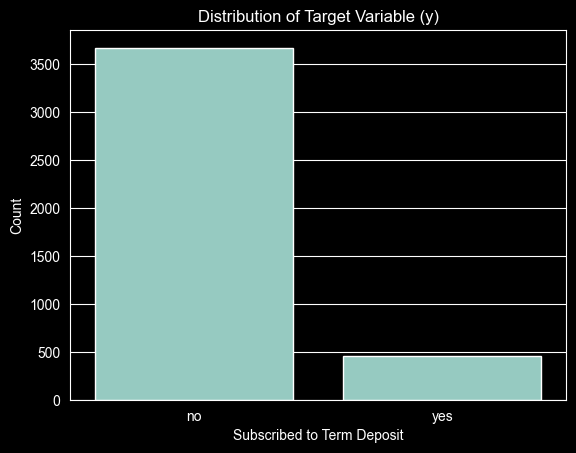

In [364]:
# distribution of the target variable
sns.countplot(x=TARGET, data=df)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

In [365]:
print(f'Ratio of classes in target variable:{df[TARGET].value_counts(normalize=True)}')

Ratio of classes in target variable:y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


The target is highly imbalanced, with a majority of 'no' responses. (~89% 'no' and ~10.9% 'yes'). This imbalance will need to be addressed during model training, as it can lead to biased predictions towards the majority class.

In [366]:
# Checking for missing values
# explicitly checking for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [367]:
# Checking for missing values stated as 'unknown'
unknown_values = df[cat_cols].apply(lambda x: (x == 'unknown').sum())
print(f"Count of unknown values in categorical columns: {unknown_values}, ({(unknown_values/len(df)*100).round(2)}%)\n")

Count of unknown values in categorical columns: job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64, (job             0.95
marital         0.27
education       4.05
default        19.50
housing         2.55
loan            2.55
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64%)



In [368]:
# Special sentinel in pdays: 999 means "not previously contacted"
print(f'\npdays == 999: {(df["pdays"]==999).sum()} ({(df["pdays"]==999).mean()*100:.1f}%)')


pdays == 999: 3959 (96.1%)


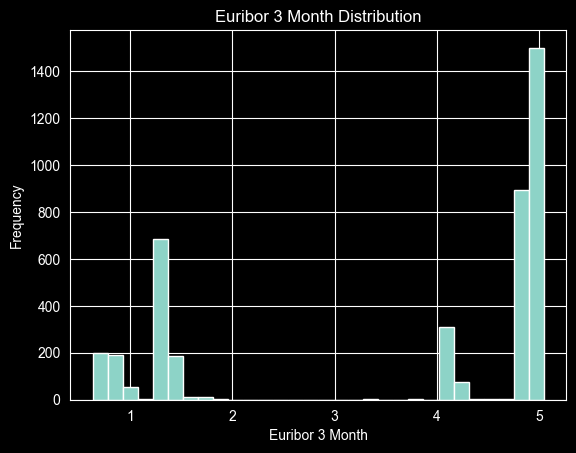

In [369]:
# age distribution
df['age'].hist(bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

 # euribor3m distribution
df['euribor3m'].hist(bins=30)
plt.title('Euribor 3 Month Distribution')
plt.xlabel('Euribor 3 Month')
plt.ylabel('Frequency')
plt.show()

The 'age' distribution suggests that the majority of clientele are between 30 and 60 years old, with a peak around 40-50.

The 'euribor3m' distribution is right-skewed, with the majority of values concentrated at the bottom (0-5), and a long tail extending to higher values. This shows that the majority of clients were contacted during periods of low interest rates, which may have influenced their decision to open a term deposit.

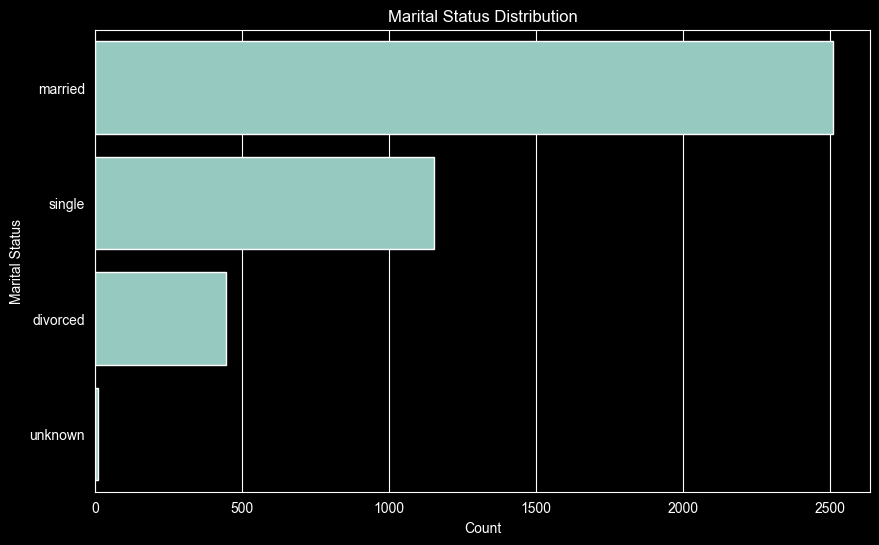

In [370]:
# job distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Job Distribution')
plt.xlabel('Count')
plt.ylabel('Job')

#education distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.title('Education Distribution')
plt.xlabel('Count')
plt.ylabel('Education')

# marital distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='marital', data=df, order=df['marital'].value_counts().index)
plt.title('Marital Status Distribution')
plt.xlabel('Count')
plt.ylabel('Marital Status')



According to the 'job' distribution, the most common vocations among clients are "blue-collar", "management", and "technician".

The 'education' distribution shows that the majority of clients have a secondary education, while fewer have a primary or tertiary education. These distributions contain information about the clients' demographic features, which may influence their likelihood of subscribing to a term deposit.
The 'marital' status distribution shows that most clients are married, followed by single and divorced.

### **Special consideration for 'pdays':**
 999 indicates "not previously contacted". This is a form of implicit missingness. (Drawing this in a graph will create extreme skewness, duo to the unreasonambly big number) We will handle this by creating a new binary feature indicating whether the client was previously contacted, and then replacing 999 with 0 in the pdays column. This way, we can retain all the data without losing any information due to imputation or deletion.

---
## Data Slitting

Data splitting is a crucial step in the machine learning pipeline, as it allows us to evaluate the performance of our model on unseen data. We will split the dataset into a training set and a test set. The training set will be used to train the model, while the test set will be used to evaluate its performance. Data leakage is a cocern when information from the test set is used during training, which can lead to overly optimistic performance estimates. To prevent it we need to split the data before any preprocessing steps that learn from the data (e.g., imputation, encoding, scaling). This way, the test set remains completely unseen and provides a reliable estimate of how the model will perform on new, unseen data.

**Proportions:**
We will use 70% train, 15% validation, and 15% test split. With ~4,100 rows gives us ~600 significant number for reliable evaluation of the model's performance on the test set.

**Stratification**:
  on 'y' is crucial: the class imbalance (~12% positive) means that random splits may result in significantly different class ratios, inflating or deflating assessment measures.

In [371]:
X=df.drop(columns=[TARGET])
y = df[TARGET]

# first split into train and temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# second split temp into val and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


print(f'Train: {X_train.shape[0]} rows ({(y_train=="yes").mean()*100:.1f}% positive)')
print(f'Val:   {X_val.shape[0]} rows ({(y_val=="yes").mean()*100:.1f}% positive)')
print(f'Test:  {X_test.shape[0]} rows ({(y_test=="yes").mean()*100:.1f}% positive)')

Train: 2883 rows (11.0% positive)
Val:   618 rows (11.0% positive)
Test:  618 rows (10.8% positive)


Stratification preserves the ~12% positive rate across all three splits, as confirmed above.

---
# Managing Missing Values

All transformations are derived from the **training set structure only** — here, since the strategy involves no statistical estimation (no mean/mode imputation), there is no fitting step that could leak. However, for consistency in a sklearn Pipeline, these would be fit on train.

All missingness in this dataset is implicit: job, marital, education, default, housing, loan, contact, month, day_of_week, and poutcome have 'unknown' as a category, while pdays has 999 to indicate "not previously contacted". We will handle these missing values by treating 'unknown' as a separate category for the categorical variables and replacing 999 for 0 value for pdays. This way, we can retain all the data without losing any information due to imputation or deletion.

In [372]:
def handle_pdays(X):
    X = X.copy()
    X['was_contacted_before'] = (X['pdays'] != 999).astype(int)
    X = X.drop(columns=['pdays'])  # Replace pdays with the binary indicator. We dont realy want to keep the pdays column because it has a very skewed distribution and the 999 value is not meaningful for modeling. The new binary feature captures the essential information about whether the client was previously contacted, which is more relevant for our prediction task.
    return X

X_train = handle_pdays(X_train)
X_val = handle_pdays(X_val)
X_test = handle_pdays(X_test)

print('was_contacted_before value counts in training set:\n', X_train['was_contacted_before'].value_counts())

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns ### change to string because of the new column
print('unknown values in categorical columns after handling pdays:\n', X_train[cat_cols].apply(lambda x: (x == 'unknown').sum()))

was_contacted_before value counts in training set:
 was_contacted_before
0    2764
1     119
Name: count, dtype: int64
unknown values in categorical columns after handling pdays:
 job             25
marital          7
education      112
default        577
housing         65
loan            65
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64


The `unknown` categories are retained as legitimate categories that will be handled naturally by One-Hot Encoding in the next step.


---
## Encoding Categorical Variables

### Nominal versus Ordinal Classification
**Ordinal** (a meaningful order exists):
- 'education': 'illiterate < basic.4y < basic.6y < basic.9y < high.school < professional.course < university.degree < unknown'

**Nominal** (without intrinsic order):
- 'job','marital', 'contact','month', 'day_of_week', 'poutcome', 'default', 'housing', 'loan'

## Encoding Strategy

- **Ordinal variables → 'OrdinalEncoder'**: Maintains order, enabling Logistic Regression to learn monotonic correlations without increasing dimensionality.
- **Nominal variables → 'OneHotEncoder' (OHE)**: No artificial ordering applied. We remove one category per variable to avoid the dummy variable trap (multicollinearity).

**All encoders are only used on the training set** to avoid leaking the distribution of unseen categories into the model.

## Impact on Logistic Regression
- OHE increases dimensionality (each category becomes a binary column), therefore coefficients can be directly interpreted as log-odds for that category versus the discarded reference.
- Ordinal encoding maintains a single column while assuming equidistant steps, which is appropriate for 'education' given its natural progression.- These encodings enable the linear decision boundary to function properly in feature space.

In [373]:
print("Categorical variables: ",cat_cols)

Categorical variables:  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')


In [374]:
# Define ordinal order for education
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                   'high.school', 'professional.course', 'university.degree', 'unknown']

ordinal_cols = ['education']
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

print('Ordinal columns:', ordinal_cols)
print('Nominal columns:', nominal_cols)

Ordinal columns: ['education']
Nominal columns: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [375]:
# we build the encoder
ordinal_enc = OrdinalEncoder(categories=[education_order], handle_unknown='use_encoded_value', unknown_value=-1)
nominal_enc = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

cat_transformer = ColumnTransformer(transformers=[
    ('ordinal', ordinal_enc, ordinal_cols),
    ('nominal', nominal_enc, nominal_cols)
], remainder='passthrough')

# fit the encoder on the training data
X_train_enc = cat_transformer.fit_transform(X_train)
X_val_enc = cat_transformer.transform(X_val)
X_test_enc = cat_transformer.transform(X_test)

# reconstructing the feature names after encoding
nominal_feature_names = cat_transformer.named_transformers_['nominal'].get_feature_names_out(nominal_cols)
num_passthrough_cols = [col for col in X_train.columns if col not in ordinal_cols + nominal_cols ]
all_cols_enc = list(ordinal_cols) + list(nominal_feature_names )+ num_passthrough_cols

X_train_enc = pd.DataFrame(X_train_enc, columns=all_cols_enc)
X_val_enc = pd.DataFrame(X_val_enc, columns=all_cols_enc)
X_test_enc = pd.DataFrame(X_test_enc, columns=all_cols_enc)

print('Dimension of training set before encoding:', X_train.shape[1])
print('Dimension of training set after encoding:', X_train_enc.shape[1])

Dimension of training set before encoding: 20
Dimension of training set after encoding: 47


The encoding increased the dimensionality of the dataset from 20 to 47 colums. OHE introduces one binary feature per category level (minus one reference), enabling the linear model to fit category-specific intercepts.

---
## Feature Scaling

All numerical features are on different scales (e.g., `age` ∈ [18, 98], `euribor3m` ∈ [0.6, 5.0], `nr.employed` ∈ [4963, 5228]). The binary OHE columns already lie in [0, 1] and the ordinal column is already low-magnitude — but standardizing them is harmless.

### Scaling Strategy: **StandardScaler** (z-score normalization)
**Justification:**
- Logistic regression optimises a convex loss using gradient descent. When features have significantly different scales, the loss surface becomes extended along large-scale dimensions, slowing convergence or generating numerical instability.
- Standardisation ensures that all features contribute similarly to the gradient update.
- **Comparable coefficients:** Following standardisation, the magnitude of LR coefficients reflects the relative relevance of each feature; otherwise, coefficients are muddled by feature scale.
- **Regularisation (L2):**'sklearn's LogisticRegression' uses L2 by default. L2 penalises the squared magnitude of coefficients. Without scaling, large-scale characteristics are penalised less in absolute terms, rendering regularisation imbalanced.


**Scaler is fitted solely on training data**; fitting on val/test would leak their mean and variance, providing the scaler with knowledge of the test distribution.

In [376]:
# we build the scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled = scaler.transform(X_val_enc)
X_test_scaled = scaler.transform(X_test_enc)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_cols_enc)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=all_cols_enc)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=all_cols_enc)

print('Scaling is done.')
print('Training mean (should be ~0):', X_train_scaled.mean().mean().round(2))
print('Training std (should be ~1):', X_train_scaled.std().mean().round(2))

Scaling is done.
Training mean (should be ~0): -0.0
Training std (should be ~1): 1.0


---
## 7. Feature Selection

Feature selection must use the **training set only**. Computing variances or correlations on the full dataset would incorporate test distribution information into the selection decision, constituting leakage.

### Low Variance Features


In [377]:
# Threshold: variance < 0.01 (feature is nearly constant)
var_threshold = VarianceThreshold(threshold=.01)
var_threshold.fit(X_train_scaled)

low_var_mask = ~var_threshold.get_support()
low_var_features = X_train_scaled.columns[low_var_mask].tolist()

print('Low variance features (var<.01):', low_var_features)
if not low_var_features:
    print('No low variance features found.')

Low variance features (var<.01): []
No low variance features found.


In [378]:
# Apply variance filter
# this is not needed in this case since we found no low-variance features, but we will do it for the sake of the pipeline
selected_features = X_train_scaled.columns[var_threshold.get_support()].tolist()
X_train_sel = X_train_scaled[selected_features]
X_val_sel   = X_val_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

print(f'Features after variance filter: {len(selected_features)}')

Features after variance filter: 47


Low-variance features contain little to no variability between samples, hence they give little information for separating across classes. Removing them could reduce noise levels and enhance model performance. In this scenario, we discovered no low-variance features, indicating that all characteristics have some variability and may contribute to the model's predictive capacity.

In [379]:
# correlation analysis
corr_matrix = X_train_sel.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row,col]) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.85]

print('Highly correlated feature pairs (corr>0.85):')
for feat1, feat2, corr_value in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    print(f'{feat1} - {feat2}: {corr_value:.2f}')

Highly correlated feature pairs (corr>0.85):
loan_unknown - housing_unknown: 1.00
euribor3m - emp.var.rate: 0.97
nr.employed - euribor3m: 0.94
was_contacted_before - poutcome_success: 0.93
nr.employed - emp.var.rate: 0.90


### Correlation analysis


In [380]:
# Compute correlation matrix on training set only
corr_matrix = X_train_sel.corr().abs()

# Find pairs with |r| > 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] > 0.85]

print('Highly correlated pairs (|r| > 0.85):')
for a, b, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(f'  {a} — {b}: {r:.2f}')

Highly correlated pairs (|r| > 0.85):
  loan_unknown — housing_unknown: 1.00
  euribor3m — emp.var.rate: 0.97
  nr.employed — euribor3m: 0.94
  was_contacted_before — poutcome_success: 0.93
  nr.employed — emp.var.rate: 0.90


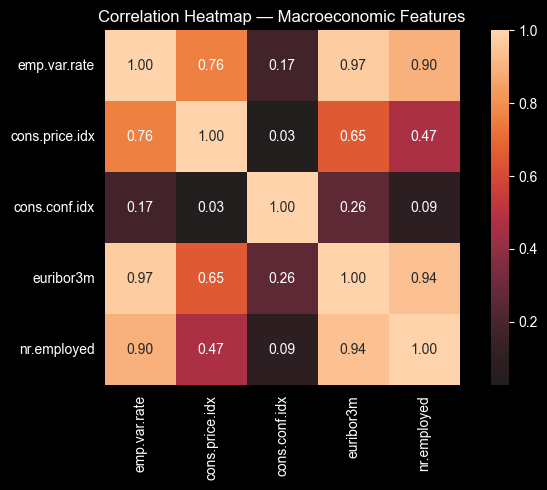

In [381]:

# visualize correlation heatmap
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
macro_in_sel = [c for c in macro_cols if c in selected_features]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(X_train_sel[macro_in_sel].corr(), annot=True, fmt='.2f',
            center=0, ax=ax, square=True) # if I want pink add: cmap='PuRd',
ax.set_title('Correlation Heatmap — Macroeconomic Features')
plt.tight_layout()
plt.show()

The macroeconomic features (`euribor3m`, `emp.var.rate`, and `nr.employed`) are closely connected, since they all reflect the same underlying economic cycle. Multicollinearity in Logistic Regression increases coefficient variance and destabilises interpretation. We eliminate the most redundant ones, leaving 'euribor3m' (the most direct rate indication) and 'cons.conf.idx' (an independent consumer sentiment signal).

In [382]:
# Remove highly correlated features
# duo to the corellation > 0.94 we will remove 'emp.var.rate' and 'nr.employed' and keep 'euribor3m' and 'cons.conf.idx' (euribor3m — emp.var.rate: 0.970; nr.employed — euribor3m: 0.942)

cols_to_drop_corr= [c for c in ['emp.var.rate', 'nr.employed'] if c in selected_features ]
print('Dropping highly correlated features:', cols_to_drop_corr)

X_train_final = X_train_sel.drop(columns=cols_to_drop_corr)
X_val_final   = X_val_sel.drop(columns=cols_to_drop_corr)
X_test_final  = X_test_sel.drop(columns=cols_to_drop_corr)

print('Final feature count after selection:', X_train_final.shape[1])

Final feature count after selection: 45


---
## Addressing Class Imbalance

In [383]:
# Quantify imbalance
print('Class distribution in training set:')
print(y_train.value_counts())
print(f'Imbalance ratio (no/yes): {(y_train=="no").sum()}/{ (y_train=="yes").sum()} = {(y_train=="no").sum()/(y_train=="yes").sum():.1f}:1')

Class distribution in training set:
y
no     2567
yes     316
Name: count, dtype: int64
Imbalance ratio (no/yes): 2567/316 = 8.1:1


The imbalance of 8:1 is a matter for concern:
- A simple model predicting 'no' for every customer achieves ~88% accuracy, indicating the Zero Rule baseline is surprisingly high.
- Accuracy is deceptive since it fails to discriminate between false positives (wasted calls) and false negatives (missed conversions).
- Precision and Recall on the minority class are more informative—the bank is concerned with locating actual subscribers (high Recall) rather than spending resources on non-subscribers (high Precision).

## Resampling Strategy: **SMOTE** (Synthetic Minority Over-Sampling Technique)

SMOTE creates synthetic minority samples by interpolating existing minority cases rather than duplicating them. This:- Prevents overfitting to repeated points (risk of random oversampling)
- Adds new coverage to the minority class feature area.- Is suitable for tabular and numerical data (after encoding).

**SMOTE applies just to the training set.** To provide accurate performance estimates, the validation and test sets must retain the original distribution. If SMOTE was used before splitting, synthetic points might emerge in both training and testing, resulting in data leakage and overoptimistic assessment.

In [384]:
y_train_b = (y_train == 'yes').astype(int).values  # Convert to binary labels for SMOTE
y_val_b = (y_val == 'yes').astype(int).values
y_test_b = (y_test == 'yes').astype(int).values

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train_b)

print('Before SMOTE:', pd.Series(y_train_b).value_counts())
print('After SMOTE:', pd.Series(y_train_res).value_counts())
print('New imbalance ratio:', (y_train_res==0).sum()/(y_train_res==1).sum(), ':1')

Before SMOTE: 0    2567
1     316
Name: count, dtype: int64
After SMOTE: 0    2567
1    2567
Name: count, dtype: int64
New imbalance ratio: 1.0 :1


after SMOTE the taining set is palanced 1:1. Vlidation and test remain at the original ~12% positive rate, ensuring that performance metrics reflect real-world conditions.

---
## Training a Logistic Regression Model

In [385]:
# Train logistic regression on the resampled training set
model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
model.fit(X_train_res, y_train_res)

y_val_pred = model.predict(X_val_sel.values)

acc  = accuracy_score(y_val_b, y_val_pred)
prec = precision_score(y_val_b, y_val_pred)
rec  = recall_score(y_val_b, y_val_pred)
f1   = f1_score(y_val_b, y_val_pred)

zero_rule_acc = (y_val_b == 0).mean()  # always predict majority class

print(f'Zero Rule Baseline Accuracy: {zero_rule_acc:.3f}')
print(f'Logistic Regression Accuracy: {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall:    {rec:.3f}')
print(f'F1 Score:  {f1:.3f}')

/Users/rayametche/PycharmProjects/ML-fundamentals-2026/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rayametche/PycharmProjects/ML-fundamentals-2026/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rayametche/PycharmProjects/ML-fundamentals-2026/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/rayametche/PycharmProjects/ML-fundamentals-2026/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/rayametche/PycharmProjects/ML-fundamentals-2026/.venv/lib/python